### Работа с табличными данными - лабораторная работа № 3

## ИУ5 ОАД

### О задании

Задание состоит из двух разделов, посвященных работе с табличными данными с помощью библиотеки pandas и визуализации с помощью matplotlib. В первом разделе вам предстоит выполнить базовые задания с помощью вышеуказанных библиотек, а во втором распределить студентов по курсам. Задачи в рамках одного раздела рекомендуется решать в том порядке, в котором они даны в задании.

## 0. Введение

Сейчас мы находимся в jupyter-ноутбуке (или ipython-ноутбуке). Это удобная среда для написания кода, проведения экспериментов, изучения данных, построения визуализаций и других нужд, не связанных с написанием production-кода. 

Ноутбук состоит из ячеек, каждая из которых может быть либо ячейкой с кодом, либо ячейкой с текстом размеченным и неразмеченным. Текст поддерживает markdown-разметку и формулы в Latex.

Для работы с содержимым ячейки используется *режим редактирования* (*Edit mode*, включается нажатием клавиши **Enter** после выбора ячейки), а для навигации между ячейками искользуется *командный режим* (*Command mode*, включается нажатием клавиши **Esc**). Тип ячейки можно задать в командном режиме либо с помощью горячих клавиш (**y** to code, **m** to markdown, **r** to edit raw text), либо в меню *Cell -> Cell type*. 

После заполнения ячейки нужно нажать *Shift + Enter*, эта команда обработает содержимое ячейки: проинтерпретирует код или сверстает размеченный текст.

In [1]:
# ячейка с кодом, при выполнении которой появится output
2 + 2

4

Ячейка с неразмеченным текстом.

Попробуйте создать свои ячейки, написать какой-нибудь код и текст какой-нибудь формулой.

In [3]:
# your code
print(123)

123


[Здесь](https://athena.brynmawr.edu/jupyter/hub/dblank/public/Jupyter%20Notebook%20Users%20Manual.ipynb) находится <s>не</s>большая заметка о используемом языке разметки Markdown. Он позволяет:

0. Составлять упорядоченные списки
1. Выделять *текст* <s>при</s> **необходимости**
2. Добавлять [ссылки](http://imgs.xkcd.com/comics/the_universal_label.png)


* Составлять неупорядоченные списки

Делать вставки с помощью LaTex:
    
$
\left\{
\begin{array}{ll}
x = 16 \sin^3 (t) \\ 
y = 13 \cos (t) - 5 \cos (2t) - 2 \cos (3t) - \cos (4t) \\
t \in [0, 2 \pi]
\end{array}
\right.$

А ещё можно вставлять картинки, или гифки, или что захотите:

<img src="https://media1.tenor.com/images/9b8fbe9214504bcf6c60fe4e4f7e114e/tenor.gif?itemid=5416416" style="width: 400px">

### Google Colab

Что за колаб? 

**Google Colab (Colaboratory)** это **Jupyter Notebook + Cloud + Google Drive.**

Компания Google предоставляет возможность бесплатно запускать ноутбуки (предварительно загрузив их на свой гугл-диск) прямо в облаке. При этом вам не требуется установка никаких пакетов на свою машину, а работать можно прямиком из браузера. Вот ссылка:

https://colab.research.google.com

При использовании вы увидете много сходств с jupyter ноутбуком. Одним из преимуществ является доступность GPU, соответствующую опцию можно активировать в настройках сервиса. При желании вы сможете найти в интернете много туториалов по использованию или разобраться самостоятельно =)

## 1. Табличные данные и Pandas

Pandas — удобная библиотека для работы с табличными данными в Python, если данных не слишком много и они помещаются в оперативную память вашего компьютера. Несмотря на неэффективность реализации и некоторые проблемы, библиотека стала стандартом в анализе данных.

Основной объект в pandas — это DataFrame, представляющий собой таблицу с именованными колонками различных типов, индексом (может быть многоуровневым). DataFrame можно создавать, считывая таблицу из файла или задавая вручную из других объектов.

В этой части потребуется выполнить несколько небольших заданий. Можно пойти двумя путями: сначала изучить материалы, а потом приступить к заданиям, или же разбираться "по ходу". Выбирайте сами.

Материалы:
1. [Pandas за 10 минут из официального руководства](http://pandas.pydata.org/pandas-docs/stable/10min.html)
2. [Документация](http://pandas.pydata.org/pandas-docs/stable/index.html) (стоит обращаться, если не понятно, как вызывать конкретный метод)
3. [Примеры использования функционала](http://nbviewer.jupyter.org/github/justmarkham/pandas-videos/blob/master/pandas.ipynb)

Многие из заданий можно выполнить несколькими способами. Не существуют единственно верного, но попробуйте максимально задействовать арсенал pandas и ориентируйтесь на простоту и понятность вашего кода. Мы не будем подсказывать, что нужно использовать для решения конкретной задачи, попробуйте находить необходимый функционал сами (название метода чаще всего очевидно). В помощь вам документация, поиск и stackoverflow.

In [45]:
%pylab inline
import pandas as pd

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


Скачаем подготовленные данные:

In [7]:
!wget  -O 'end_seminar.xlsx' -q 'https://www.dropbox.com/s/f4rm8sjc3v99p0m/_end_seminar.xlsx?dl=0'

zsh:1: command not found: wget


Для пользователей Windows: скачайте файл самостоятельно и поместите его в папку с тетрадкой. Или попробуйте один из следующих вариантов:

In [ ]:
# !powershell iwr -outf somefile https://somesite/somefile

In [ ]:
# !pip install wget
# import wget 
# wget.download('https://dropbox.com/s/f4rm8sjc3v99p0m/_end_seminar.xlsx?dl=1', 'end_seminar.xlsx')

##### В первой части задания (до раздела "Распределение студентов по курсам") использование циклов запрещается. Использование <code>vectorize</code> и  <code>apply</code>, <code>apply_along_axis</code> крайне нежелательно.

Для каждой задачи из этого раздела вы должны написать код для получения ответа, а также дать текстовый ответ, если он предполагается.

На некоторые вопросы вы можете получить путём пристального взгляда на таблицу, но это не будет засчитываться. Вы в любом случае должны получить ответ с помощью кода.

#### 1. Откройте файл с таблицей (не забудьте про её формат). Выведите последние 10 строк.

Посмотрите на данные и скажите, что они из себя представляют, сколько в таблице строк, какие столбцы? (на это не надо отвечать, просто подумайте об этом)

In [47]:
# your code
df = pd.read_excel('_end_seminar.xlsx')
print(df.tail(10))

                  timestamp                                id  rating  \
351 2020-05-18 23:58:33.903  8fe79f84f36e3a5d2d6745621321302c    1016   
352 2020-05-18 23:59:20.831  f93afd8e92c336b471aa3bbbc579aefe    1298   
353 2020-05-18 23:59:28.998  9963fc00d9405a35b894cc04a7e19855    1135   
354 2020-05-19 08:55:39.509  98c5a2548d93f26bd4195466e93178b3    1035   
355 2020-05-19 18:58:06.283  ba298cbd9be59b84bab33325e956f27e    1155   
356 2020-05-19 19:04:17.873  c5870b37ee3f672e4259dfb2fc02ed8f    1029   
357 2020-05-19 20:19:25.815  f44aea1095f9f5b8e2f5f0ed2b17891b    1060   
358 2020-05-20 11:54:38.318  d7118b44c7e8fdbbaaca226d2da6fef1    1111   
359 2020-05-23 21:16:40.916  79d14db48e4737af731960ae212d5134     966   
360 2020-05-23 21:16:40.916  f2d210ace25a841e1e58036b257d5d47    1195   

     18_group  is_mi                                           fall_1  \
351       NaN    NaN                 Безопасность компьютерных систем   
352       NaN    NaN                Высокопроизвод

#### 2. Есть ли в данных пропуски? В каких колонках? Сколько их в каждой из этих колонок?

In [49]:
# your code
print('Есть ли пропуски:', any(df.isna()))
cols = df.columns[df.isna().any()]
print('Пропуски есть в колонках:', cols.to_list())
print(df[cols].isna().sum())

Есть ли пропуски: True
Пропуски есть в колонках: ['18_group', 'is_mi', 'is_first_time', '17_group', 'blended', 'is_ml_student']
18_group         138
is_mi            343
is_first_time      2
17_group         223
blended          223
is_ml_student    304
dtype: int64


Заполните пропуски пустой строкой для строковых колонок и нулём для числовых (постарайтесь избежать перечисления названий всех столбцов).

In [51]:
# your code
df2 = df.copy()
num_cols = df2.select_dtypes(include=['number']).columns
str_cols = df2.select_dtypes(include=['object']).columns
df2[num_cols] = df2[num_cols].fillna(0)
df2[str_cols] = df2[str_cols].fillna('')
df = df2.copy()

#### 3. Посмотрите повнимательнее на колонку 'is_first_time'. 

Есть ли в ней ответы "Нет"? Сколько их?

Если вы найдете повторные обращения студентов, оставьте только самую позднюю версию. В дальнейших заданиях используйте версию данных без повторов.

<i>Обращения со значением "Нет" в 'is_first_time' могут быть как повторными, так и первичными, поскольку поле заполняли сами студенты.</i>

In [53]:
# your code
print(df.shape)
print('Кол-во "нет"', (df['is_first_time'] == 'Нет').sum())
df = df.sort_values(['id', 'timestamp'], ascending=[True, False])
df = df.drop_duplicates('id', keep='first')
print(df.shape)

(361, 16)
Кол-во "нет" 51
(347, 16)


#### 4. Ответьте на вопросы:
1. Сколько было заявок из групп 18-го года набора, а сколько из групп 17-го года?
2. Есть ли студенты с равными перцентилями (среди объединенных данных, ведь конкурс на каждый курс общий)?

In [55]:
# your code
print('Заявок 18-го года:', (df['18_group'] != 0).sum())
print('Заявок 17-го года:', (df['17_group'] != 0).sum())
print('Есть ли студенты с равными перцентилями:', df['percentile'].nunique() < df['percentile'].shape[0])

Заявок 18-го года: 213
Заявок 17-го года: 134
Есть ли студенты с равными перцентилями: True


#### 5. Какие  blended-курсы для четверокурсников существуют? На какой blended-курс записалось наибольшее количество студентов? На каком из blended-курсов собрались студенты с самым высоким средним рейтингом (выведите этот курс и количество студентов на нем)? 

In [57]:
# your code
courses = df[df['blended'] != '']['blended']
print('Курсы:', courses.unique(), '\n')
print('Самый популярный:', courses.value_counts().idxmax(), courses.value_counts().max(), '\n')

stats = df[df['blended'] != ''].groupby('blended').agg({'rating': 'mean', 'id': 'count'}).sort_values(by=['rating'], ascending=False)
best_course = stats.iloc[0]
print(f'Лучший курс: {best_course.name}\nсредний рейтинг студентов: {best_course['rating']}\nкол-во студентов: {best_course['id']}')

Курсы: ['Соревновательный анализ данных' 'DevOps'
 'Введение в дифференциальную геометрию'] 

Самый популярный: DevOps 87 

Лучший курс: Введение в дифференциальную геометрию
средний рейтинг студентов: 1210.7333333333333
кол-во студентов: 15.0


#### 6. Выясните, есть ли студенты с абсолютно одинаковыми предпочтениями по всем курсам.

Для этого сформируйте таблицу, где для каждого возможного набора курсов посчитано количество студентов, выбравших такой набор, и оставьте только строки где это количество больше 1.

В данном случае набор курсов задается упорядоченным множеством ('fall_1', 'fall_2', 'fall_3', 'spring_1', 'spring_2', 'spring_3', 'blended'). Элемент blended будет нулевым для 3-го курса.

In [59]:
# your code
df['courses'] = df['fall_1'] + '|' + df['fall_2'] + '|' + df['fall_3'] + '|' + \
df['spring_1'] + '|' + df['spring_2'] + '|' + df['spring_3'] + '|' + df['blended']
counts = df.groupby('courses').size().reset_index(name='count')
counts = counts[counts['count'] > 1]
print(counts)

                                               courses  count
0    Statistical Learning Theory|Анализ неструктури...      2
60   Байесовские методы машинного обучения|Анализ н...      2
62   Байесовские методы машинного обучения|Анализ н...      2
72   Безопасность компьютерных систем|Statistical L...      3
84   Безопасность компьютерных систем|Высокопроизво...      2
102  Безопасность компьютерных систем|Высокопроизво...      3
105  Безопасность компьютерных систем|Высокопроизво...      2
113  Безопасность компьютерных систем|Матричные выч...      2
137  Безопасность компьютерных систем|Сбор и обрабо...      2
155  Безопасность компьютерных систем|Теория баз да...      2
184  Высокопроизводительные вычисления|Безопасность...      2
201  Высокопроизводительные вычисления|Сбор и обраб...      2
244  Моделирование временных рядов|Сбор и обработка...      2
292  Сбор и обработка данных с помощью краудсорсинг...      2
313  Язык SQL|Высокопроизводительные вычисления|Тео...      2


#### 7. Найдите курсы по выбору, на которые записывались как студенты 18-го года набора, так и студенты 17-го года.

In [61]:
df['is_18'] = df['18_group'][df['18_group'] != 0]
df['is_17'] = df['17_group'][df['17_group'] != 0]

all_courses = df.melt(
    id_vars=['is_17', 'is_18'], 
    value_vars=['fall_1', 'fall_2', 'fall_3', 'spring_1', 'spring_2', 'spring_3'],
    value_name='course'
)

course_stats = all_courses.groupby('course').agg({
    'is_17': 'sum',
    'is_18': 'sum'
}).rename(columns={'is_17': 'count_17', 'is_18': 'count_18'})
print(course_stats[(course_stats['count_17'] > 0) & (course_stats['count_18'] > 0)])

                                                    count_17  count_18
course                                                                
Statistical Learning Theory                           5188.0    8256.0
Безопасность компьютерных систем                      9758.0   24143.0
Высокопроизводительные вычисления                     9608.0   12708.0
Моделирование временных рядов                         6785.0   10163.0
Принятие решений в условиях риска и неопределён...    1045.0    4062.0
Сбор и обработка данных с помощью краудсорсинга       9706.0   14442.0
Численные методы                                      2960.0    8840.0


Методом исключения найдите курсы, которые предлагались только студентам 18-го года и только студентам 17-го года.

In [63]:
# your code
print(course_stats[(course_stats['count_17'] == 0) & (course_stats['count_18'] > 0)])
print(course_stats[(course_stats['count_17'] > 0) & (course_stats['count_18'] == 0)])

                                             count_17  count_18
course                                                         
Анализ данных в бизнесе                           0.0   11640.0
Дискретная оптимизация                            0.0   15798.0
Дополнительные главы прикладной статистики        0.0    9193.0
Компьютерные сети                                 0.0   21053.0
Матричные вычисления                              0.0   13628.0
Машинное обучение 2                               0.0   14597.0
Промышленное программирование на языке Java       0.0   25655.0
Системы баз данных                                0.0   11100.0
Теория баз данных                                 0.0   10139.0
Язык SQL                                          0.0   20335.0
                                                    count_17  count_18
course                                                                
Анализ неструктурированных данных                    12082.0       0.0
Байесовские методы 

### Визуализации и matplotlib

При работе с данными часто неудобно делать какие-то выводы, если смотреть на таблицу и числа в частности, поэтому важно уметь визуализировать данные.

У matplotlib, конечно же, есть [документация](https://matplotlib.org/users/index.html) с большим количеством [примеров](https://matplotlib.org/examples/), но для начала достаточно знать про несколько основных типов графиков:
- plot — обычный поточечный график, которым можно изображать кривые или отдельные точки;
- hist — гистограмма, показывающая распределение некоторой величины;
- scatter — график, показывающий взаимосвязь двух величин;
- bar — столбцовый график, показывающий взаимосвязь количественной величины от категориальной.

В этом задании вы попробуете построить один из них. Не забывайте про базовые принципы построения приличных графиков:
- оси должны быть подписаны, причём не слишком мелко;
- у графика должно быть название;
- если изображено несколько графиков, то необходима поясняющая легенда;
- все линии на графиках должны быть чётко видны (нет похожих цветов или цветов, сливающихся с фоном);
- если отображена величина, имеющая очевидный диапазон значений (например, проценты могут быть от 0 до 100), то желательно масштабировать ось на весь диапазон значений (исключением является случай, когда вам необходимо показать малое отличие, которое незаметно в таких масштабах);
- сетка на графике помогает оценить значения в точках на глаз, это обычно полезно, поэтому лучше ее отрисовывать;
- если распределение на гистограмме имеет тяжёлые хвосты, лучше использовать логарифмическую шкалу.

Еще одна билиотека для визуализации: [seaborn](https://jakevdp.github.io/PythonDataScienceHandbook/04.14-visualization-with-seaborn.html) (обычно сокращается до sns). Это настройка над matplotlib, иногда удобнее и красивее делать визуализации через неё. 

**5 пунктов после которых ваши графики не будут прежними:**
- для красивой картинки <code>%config InlineBackend.figure_format = 'retina'</code>
- задаем размер (почти) всех графиков (можно выбрать другие значения) <code>plt.rcParams['figure.figsize'] = 8, 5</code>
- размер шрифта подписей графиков <code>plt.rcParams['font.size'] = 12</code>
- формат в котором сохраняется изображение <code>mpl.rcParams['savefig.format'] = 'pdf'</code>
- sns – seaborn, добавляет решетку <code>sns.set_style('darkgrid')</code>

Добавьте эти функции в ячейку ниже. Каждый график все равно придется настраивать отдельно, но указанные строчки позволят значительно упростить процесс.  

In [65]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# your code
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.figsize'] = 8, 5
plt.rcParams['font.size'] = 12
mpl.rcParams['savefig.format'] = 'pdf'
sns.set_style('darkgrid')

#### 8. Постройте график средних рейтингов по дням получения ответов (bar plot).

         date       rating
0  2020-05-14  1160.277778
1  2020-05-15   719.866667
2  2020-05-16   736.400000
3  2020-05-17   915.027027
4  2020-05-18   827.352679
5  2020-05-19   761.142857
6  2020-05-20   689.500000
7  2020-05-21   584.000000
8  2020-05-23  1080.500000
9  2020-05-24   670.500000


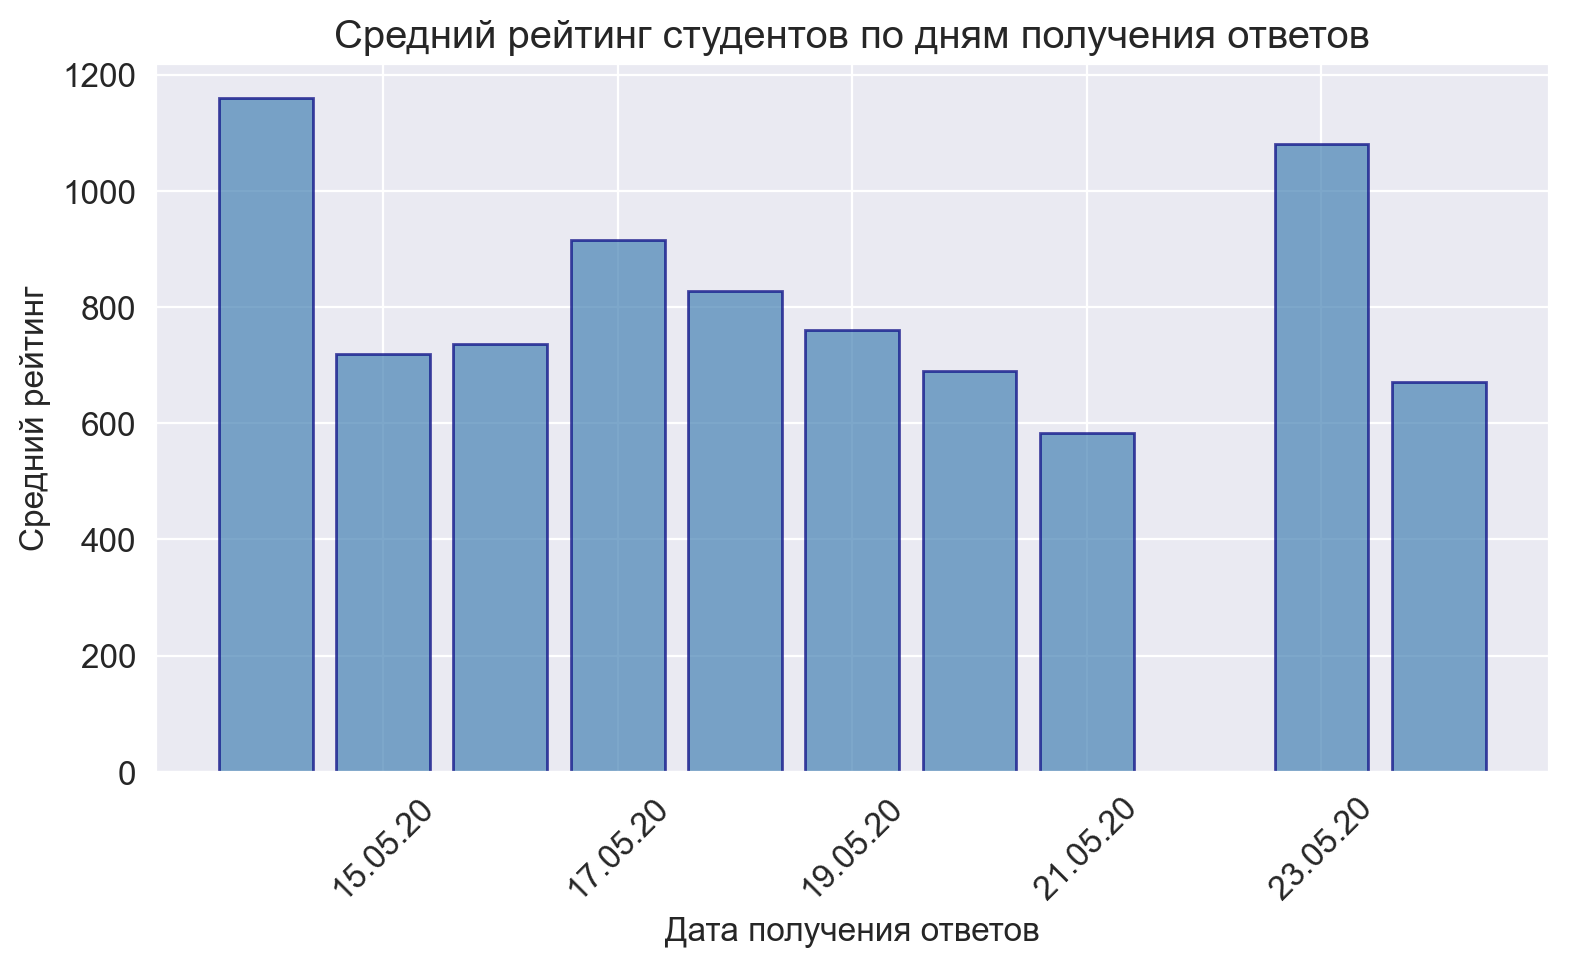

In [67]:
# your code
df['date'] = pd.to_datetime(df['timestamp']).dt.date
daily_ratings = df.groupby('date')['rating'].mean().reset_index()
daily_ratings = daily_ratings.sort_values('date')
print(daily_ratings)

plt.bar(daily_ratings['date'], daily_ratings['rating'], 
        color='steelblue', alpha=0.7, edgecolor='navy')
plt.xlabel('Дата получения ответов')
plt.ylabel('Средний рейтинг')
plt.title('Средний рейтинг студентов по дням получения ответов')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d.%m.%y'))
plt.tight_layout()
plt.savefig('daily_ratings_barplot.pdf', bbox_inches='tight', dpi=300)
plt.show()

Сохраните график в формате pdf (так он останется векторизованным).

In [454]:
# your code

### 2. Распределение студентов по курсам.

<span style="color:red">!!!ВНИМАТЕЛЬНО ИЗУЧИТЕ ТЕКСТ НИЖЕ!!!</span>.

<span style="color:orange">Если во время выполнения заданий у вас вознинут вопросы -- еще раз перечитайте текст целиком, скорее всего ответы уже содержатся в нем.</span>

Теперь вам нужно распределить студентов по осенним курсам по выбору, учитывая их предпочтения.

Алгоритм распределения студентов по курсам:
1. По умолчанию на каждой дисциплине по выбору у 3 и 4 курсов может учиться 1 группа (до 30 студентов). Исключения описаны ниже. На blended-дисциплинах для четверокурсников количество мест не ограничено.
2. Проводится первая волна отбора. Для каждой дисциплины формируется список тех, кто указал её первым приоритетом (если студент должен выбрать два курса по выбору, то для него дисциплины, которые он указал первым и вторым приоритетом, рассматриваются как дисциплины первого приоритета). Если желающих больше, чем мест, то выбирается топ по перцентилю рейтинга.
3. На дисциплинах, где остались места после первой волны, формируются списки тех, кто выбрал их вторым приоритетом и еще не прошел на необходимое количество курсов. Места заполняются лучшими по перцентилю рейтинга студентами. После этого проводится такая же процедура для дисциплин третьего приоритета.
4. Если студент не попал на необходимое количество курсов по итогам трёх волн, с ним связывается учебный офис и решает вопрос в индивидуальном порядке.

Обращаем ваше внимание на следующие детали:
- Конкурс на каждый курс общий для 3-го и 4-го курса

- По умолчанию студент выбирает один осенний и один весенний курс по выбору, а также четверокурсники выбирают один blended-курс. Студенты групп 17-го года специализаций МОП и ТИ выбирают по 2 осенних и 2 весенних курса по выбору, также студенты групп 18' специализации МИ выбирают 2 осенних курса. <i>Для студентов, которые выбирают 2 курса (например, осенних) первый приоритет — <code>fall_1</code> и <code>fall_2</code>, второй приоритет — <code>fall_3</code>. Такие студенты участвуют только в двух волнах отбора</i>.

- Студенты специализации МОП не могут выбрать весенним курсом по выбору Машинное обучение 2. **Если студент специализации МОП выбрал Машинное обучение 2, то его приоритеты сдвигаются.** Из-за совпадений первого и второго курса по выбору двигать приоритеты не надо.

- Blended-курсы не трогайте, по ним не надо распределять, на другие курсы они никак не влияют.

- Заведомо известно, что в процессе распределения не возникнет ситуации, когда на одно место претендуют студенты с одинаковым перцентилем.

- Постарайтесь воздержаться от использования циклов там, где это возможно. <i>Допустимо итерироваться по <b>курсам</b>, на которые проводится отбор, и по <b>волнам</b> отбора. Если вы придумаете, как обойтись и без этих циклов, то на усмотрение проверяющего могут быть добавлены бонусные баллы. <b>Дублирование кода не признается успешным избавлением от циклов</b></i>

- На выходе ожидается файл res_fall.csv с результатами распределения на осенние курсы по выбору. Файл должен быть следующего формата:

    * Три колонки: ID, course1, course2
    
    * Если студент не попал на курс, но должен был, то вместо названия курса в ячейке должна быть строка "???"
    
    * Если студент должен выбрать только один курс, то в колонке course2 для него должна стоять строка "-"
    
    * Если студент должен выбрать два курса по выбору, то порядок в колонках course1 и course2 не важен.
    
    * hint: для сохранения воспользуйтесь df.to_csv('solution.csv', index=None)
    

Для работы вам могут понадобиться следующие данные:

- Результаты опроса (вы уже использовали этот файл в первой части задания, но на всякий случай ссылка: https://www.dropbox.com/s/f4rm8sjc3v99p0m/_end_seminar.xlsx?dl=0)

- Соответствие номеров групп специализациям:

    * 171, 172 - МОП; 173 - ТИ; 174 — АДИС; 175, 176 — РС; 177 — АПР
    
    * У студентов 18-го года номера групп соответствуют номерам до распределения по специализациям. Это означает, что по номеру группы 18* нельзя однозначно определить специализацию студента. При этом в рамках распределения важно знать информацию только о двух из них: МОП и МИ. Эти знание можно получить из колонок 'is_ml_student
' и 'is_mi' соответственно.

- Ограничения по количеству мест на курсах по выбору:

    * Осенние: везде 30 мест, кроме Statistical Learning Theory (60 мест), Высокопроизводительных вычислений (60 мест), Анализа неструктурированных данных ($\infty$ мест)

    * Весенние: везде 30 мест, кроме Обучения с подкреплением (60 мест), Анализа данных в бизнесе (60 мест).


Кстати, убедитесь, что в данных больше нет пропусков и повторных записей.

#### 0. Проверка

Для начала давайте убедимся, что вы успешно выполнили задания первой части и проверим ваши данные на наличие пропусков и повторов:

In [69]:
# df.drop(columns=['courses', 'is_18', 'is_17', 'date'], inplace=True)
assert df.shape[0] == 347, 'В таблице остались повторы или потеряны данные'

assert df.isna().sum().sum() == 0, 'В таблице остались пропуски'

Если вы не получили AssertionError, то можете продолжать.

#### 1. Создайте новый признак, обозначающий, сколько осенних курсов должен выбрать студент

В этом вам может помочь информация о специализации и группе стундента.

In [96]:
# (￣^￣)ゞ
def get_fall_courses_count(row):
    if row['17_group'] != 0:
        group = int(row['17_group'])
        if group in [171, 172, 173]:  # МОП и ТИ
            return 2
    if row['18_group'] != 0 and row['is_mi'] == 1:
        return 2
    return 1

df['fall_courses_needed'] = df.apply(get_fall_courses_count, axis=1)

Проверка:

In [76]:
col_name = 'fall_courses_needed'

assert(df[df['id'] == '2662600c2c37e11e62f6ee0b88452f22'][col_name] == 2).all()
assert(df[df['id'] == 'd555d2805e1d93d4f023e57dc4c8f403'][col_name] == 2).all()
assert(df[df['id'] == '8fe79f84f36e3a5d2d6745621321302c'][col_name] == 1).all()
assert(df[df['id'] == 'e4caca755ee0bdd711e18fb8084958b5'][col_name] == 1).all()

#### 2. Распределите студентов в соответствии с первым приоритетом

In [84]:
# Определяем ограничения мест на осенние курсы
fall_course_capacity = {
    'Statistical Learning Theory': 60,
    'Высокопроизводительные вычисления': 60,
    'Анализ неструктурированных данных': float('inf'),  # ∞ мест
}

# По умолчанию 30 мест для остальных курсов
default_capacity = 30

# Собираем все осенние курсы из данных
fall_courses = set()
for col in ['fall_1', 'fall_2', 'fall_3']:
    fall_courses.update(df[df[col] != ''][col].unique())

# Инициализируем структуры для распределения (ТОЛЬКО ПЕРВЫЙ ПРИОРИТЕТ)
course_students = {course: [] for course in fall_courses}  # студенты на каждом курсе
student_courses = {student_id: [] for student_id in df['id']}  # курсы каждого студента
course_capacity = {course: fall_course_capacity.get(course, default_capacity) for course in fall_courses}

# Функция для получения ПЕРВЫХ приоритетов студента
def get_first_priorities(student_row):
    priorities = []
    courses_needed = student_row['fall_courses_needed']
    
    if courses_needed == 1:
        # Для 1 курса: только fall_1 - первый приоритет
        if student_row['fall_1'] != '':
            priorities.append(student_row['fall_1'])
    else:
        # Для 2 курсов: fall_1 и fall_2 - первый приоритет
        if student_row['fall_1'] != '':
            priorities.append(student_row['fall_1'])
        if student_row['fall_2'] != '':
            priorities.append(student_row['fall_2'])
    
    return priorities

# Распределение по ПЕРВОМУ приоритету
print("Распределение по ПЕРВОМУ приоритету...")

# Собираем всех студентов с их первыми приоритетами
first_priority_applications = []

for _, student in df.iterrows():
    student_id = student['id']
    first_priorities = get_first_priorities(student)
    
    # Добавляем первые приоритеты
    for course in first_priorities:
        first_priority_applications.append({
            'student_id': student_id,
            'course': course,
            'percentile': student['percentile'],
            'student_data': student
        })

# Сортируем заявки по курсам и внутри курса по перцентилю (по возрастанию - меньший перцентиль лучше)
first_priority_applications.sort(key=lambda x: (x['course'], x['percentile']))

# Распределяем студентов по курсам на основе ПЕРВОГО приоритета
for application in first_priority_applications:
    student_id = application['student_id']
    course = application['course']
    student_data = application['student_data']
    
    # Проверяем, нужно ли студенту еще курсы
    courses_needed = student_data['fall_courses_needed']
    current_courses = student_courses[student_id]
    
    if len(current_courses) < courses_needed and len(course_students[course]) < course_capacity[course]:
        # Добавляем студента на курс
        course_students[course].append({
            'student_id': student_id,
            'percentile': application['percentile'],
            'student_data': student_data
        })
        student_courses[student_id].append(course)

# Создаем колонки для проверки is_first_place и is_last_place
def get_is_first_place(student_id):
    """Студент является первым местом, если он лучший ХОТЯ БЫ НА ОДНОМ из своих курсов"""
    student_courses_list = student_courses[student_id]
    for course in student_courses_list:
        course_students_list = course_students[course]
        if course_students_list:
            best_student = min(course_students_list, key=lambda x: x['percentile'])  # меньший перцентиль = лучше
            if best_student['student_id'] == student_id:
                return True
    return False

def get_is_last_place(student_id):
    """Студент является последним местом, если он худший ХОТЯ БЫ НА ОДНОМ из своих курсов"""
    student_courses_list = student_courses[student_id]
    for course in student_courses_list:
        course_students_list = course_students[course]
        if course_students_list:
            worst_student = max(course_students_list, key=lambda x: x['percentile'])  # больший перцентиль = хуже
            if worst_student['student_id'] == student_id:
                return True
    return False

# Добавляем колонки проверки в df_latest
df['is_first_place'] = df['id'].apply(lambda x: True if get_is_first_place(x) else np.nan)
df['is_last_place'] = df['id'].apply(lambda x: True if get_is_last_place(x) else np.nan)

print("Распределение по первому приоритету завершено!")
print(f"Студентов с is_first_place: {df['is_first_place'].notna().sum()}")
print(f"Студентов с is_last_place: {df['is_last_place'].notna().sum()}")

# Показываем статистику по курсам после первого приоритета
print("\nСтатистика распределения по курсам (после первого приоритета):")
for course, students in course_students.items():
    if students:  # только курсы со студентами
        percentiles = [s['percentile'] for s in students]
        capacity_info = f"{len(students)}/{course_capacity[course]}"
        if course_capacity[course] == float('inf'):
            capacity_info = f"{len(students)}/∞"
        print(f"{course}: {capacity_info} студентов, перцентили: {min(percentiles):.3f}-{max(percentiles):.3f}")

# Проверяем сколько студентов получили нужное количество курсов
students_with_enough_courses = 0
for student_id, courses in student_courses.items():
    student_data = df[df['id'] == student_id].iloc[0]
    if len(courses) >= student_data['fall_courses_needed']:
        students_with_enough_courses += 1

# Удаляем колонку fall_courses_needed
df.drop(columns=['fall_courses_needed'], inplace=True)
print("Колонка 'fall_courses_needed' удалена из df_latest")

Распределение по ПЕРВОМУ приоритету...
Распределение по первому приоритету завершено!
Студентов с is_first_place: 10
Студентов с is_last_place: 12

Статистика распределения по курсам (после первого приоритета):
Моделирование временных рядов: 30/30 студентов, перцентили: 0.043-0.971
Сбор и обработка данных с помощью краудсорсинга: 30/30 студентов, перцентили: 0.009-0.638
Безопасность компьютерных систем: 30/30 студентов, перцентили: 0.000-0.211
Statistical Learning Theory: 33/60 студентов, перцентили: 0.000-0.973
Матричные вычисления: 15/30 студентов, перцентили: 0.004-0.933
Принятие решений в условиях риска и неопределённости: 8/30 студентов, перцентили: 0.475-0.996
Байесовские методы машинного обучения: 24/30 студентов, перцентили: 0.014-0.906
Высокопроизводительные вычисления: 45/60 студентов, перцентили: 0.000-0.919
Язык SQL: 29/30 студентов, перцентили: 0.184-0.969
Глубинное обучение в обработке звука: 23/30 студентов, перцентили: 0.014-0.964
Теория баз данных: 14/30 студентов, пер

Здесь для проверки приведена таблица, в которой есть 2 дополнительные колонки:
    
    1) is_first_place - является ли студент лучшим по перцентили хотя бы на одном из курсов, куда он был зачислен 
    (True / NaN)
    
    2) is_last_place  - является ли студент худшим по перцентили хотя бы на одном из курсов, куда он был зачислен (True / NaN)

In [86]:
# !wget  -O '2_task_check.csv' -q 'https://www.dropbox.com/s/v8o2zzq3iz5gc9w/_2_task_check.csv?dl=0'
check_df = pd.read_csv('_2_task_check.csv')

После распределения студентов в соответствии с первым приоритетом добавьте в свой датафрейм аналогичные признаки и запустите проверку:

In [92]:
fir_col_name = 'is_first_place'
last_col_name = 'is_last_place'
# df.drop(columns=['fall_courses_needed'], inplace=True)
assert((df[df[fir_col_name].isna() == False][['id']].sort_values('id').reset_index(drop=True)
        ==
        check_df[check_df['is_first_place'].isna() == False][['id']].sort_values('id').reset_index(drop=True)
       ).id.values).all()


assert((df[df[last_col_name].isna() == False][['id']].sort_values('id').reset_index(drop=True)
       == 
       check_df[check_df['is_last_place'].isna() == False][['id']].sort_values('id').reset_index(drop=True)
      ).id.values).all()

#### 3. Проведите все три волны отбора студентов на курсы по выбору

In [98]:
# (￣^￣)ゞ
# (￣^￣)ゞ
def get_fall_courses_count(row):
    if row['17_group'] != 0:
        group = int(row['17_group'])
        if group in [171, 172, 173]:  # МОП и ТИ
            return 2
    if row['18_group'] != 0 and row['is_mi'] == 1:
        return 2
    return 1

df['fall_courses_needed'] = df.apply(get_fall_courses_count, axis=1)
course_students = {course: [] for course in fall_courses}
student_courses = {student_id: [] for student_id in df['id']}

def get_all_priorities(student_row):
    priorities = []
    courses_needed = student_row['fall_courses_needed']    
    if courses_needed == 1:
        if student_row['fall_1'] != '':
            priorities.append((1, student_row['fall_1']))
        if student_row['fall_2'] != '':
            priorities.append((2, student_row['fall_2']))
        if student_row['fall_3'] != '':
            priorities.append((3, student_row['fall_3']))
    else:
        if student_row['fall_1'] != '':
            priorities.append((1, student_row['fall_1']))
        if student_row['fall_2'] != '':
            priorities.append((1, student_row['fall_2']))
        if student_row['fall_3'] != '':
            priorities.append((2, student_row['fall_3']))
    
    return priorities

def distribute_by_priority(priority_level):    
    priority_applications = []
    for _, student in df.iterrows():
        student_id = student['id']
        all_priorities = get_all_priorities(student)
        current_courses = student_courses[student_id]
        courses_needed = student['fall_courses_needed']
        
        if len(current_courses) < courses_needed:
            for priority, course in all_priorities:
                if priority == priority_level:
                    priority_applications.append({
                        'student_id': student_id,
                        'course': course,
                        'percentile': student['percentile'],
                        'student_data': student
                    })
    
    priority_applications.sort(key=lambda x: (x['course'], x['percentile']))
    
    distributed_count = 0
    for application in priority_applications:
        student_id = application['student_id']
        course = application['course']
        student_data = application['student_data']
        
        courses_needed = student_data['fall_courses_needed']
        current_courses = student_courses[student_id]
        
        if (len(current_courses) < courses_needed and 
            len(course_students[course]) < course_capacity[course]):
            
            course_students[course].append({
                'student_id': student_id,
                'percentile': application['percentile'],
                'student_data': student_data
            })
            student_courses[student_id].append(course)
            distributed_count += 1

distribute_by_priority(1)
distribute_by_priority(2)
distribute_by_priority(3)

final_results = []
for student_id in df['id']:
    student_data = df[df['id'] == student_id].iloc[0]
    courses = student_courses[student_id]
    courses_needed = student_data['fall_courses_needed']
    if courses_needed == 1:
        course1 = courses[0] if len(courses) > 0 else "???"
        course2 = "-"
    else:
        course1 = courses[0] if len(courses) > 0 else "???"
        course2 = courses[1] if len(courses) > 1 else "???"
    final_results.append({
        'ID': student_id,
        'course1': course1,
        'course2': course2
    })

results_df = pd.DataFrame(final_results)
results_df.to_csv('res_fall.csv', index=None)
df.drop(columns=['fall_courses_needed'], inplace=True)

**Дополнительное задание. Распределите таким же образом студентов еще и на весенние курсы по выбору.**

Если ваш код был хорошо структурирован, то это не составит проблем. 

In [100]:
# (￣^'￣)ゞ
spring_course_capacity = {
    'Обучение с подкреплением': 60,
    'Анализ данных в бизнесе': 60,
}
default_capacity = 30

spring_courses = set()
for col in ['spring_1', 'spring_2', 'spring_3']:
    spring_courses.update(df[df[col] != ''][col].unique())

spring_course_students = {course: [] for course in spring_courses}
spring_student_courses = {student_id: [] for student_id in df['id']}
spring_course_capacity = {course: spring_course_capacity.get(course, default_capacity) for course in spring_courses}


def get_spring_courses_count(row):
    if row['17_group'] != 0:
        group = int(row['17_group'])
        if group in [171, 172, 173]:
            return 2
    return 1

df['spring_courses_needed'] = df.apply(get_spring_courses_count, axis=1)

def is_course_available_for_student(student_row, course_name):
    if (student_row['17_group'] in [171, 172] and 'Машинное обучение 2' in course_name):
        return False
    return True


def get_spring_priorities(student_row):
    priorities = []
    courses_needed = student_row['spring_courses_needed']

    if courses_needed == 1:
        if student_row['spring_1'] != '' and is_course_available_for_student(student_row, student_row['spring_1']):
            priorities.append((1, student_row['spring_1']))
        if student_row['spring_2'] != '' and is_course_available_for_student(student_row, student_row['spring_2']):
            priorities.append((2, student_row['spring_2']))
        if student_row['spring_3'] != '' and is_course_available_for_student(student_row, student_row['spring_3']):
            priorities.append((3, student_row['spring_3']))
    else:
        if student_row['spring_1'] != '' and is_course_available_for_student(student_row, student_row['spring_1']):
            priorities.append((1, student_row['spring_1']))
        if student_row['spring_2'] != '' and is_course_available_for_student(student_row, student_row['spring_2']):
            priorities.append((1, student_row['spring_2']))
        if student_row['spring_3'] != '' and is_course_available_for_student(student_row, student_row['spring_3']):
            priorities.append((2, student_row['spring_3']))

    return priorities


def distribute_spring_by_priority(priority_level):
    priority_applications = []

    for _, student in df.iterrows():
        student_id = student['id']
        all_priorities = get_spring_priorities(student)
        current_courses = spring_student_courses[student_id]
        courses_needed = student['spring_courses_needed']

        if len(current_courses) < courses_needed:
            for priority, course in all_priorities:
                if priority == priority_level:
                    priority_applications.append({
                        'student_id': student_id,
                        'course': course,
                        'percentile': student['percentile'],
                        'student_data': student
                    })

    priority_applications.sort(key=lambda x: (x['course'], x['percentile']))

    distributed_count = 0
    for application in priority_applications:
        student_id = application['student_id']
        course = application['course']
        student_data = application['student_data']

        courses_needed = student_data['spring_courses_needed']
        current_courses = spring_student_courses[student_id]

        if (len(current_courses) < courses_needed and
                len(spring_course_students[course]) < spring_course_capacity[course]):
            spring_course_students[course].append({
                'student_id': student_id,
                'percentile': application['percentile'],
                'student_data': student_data
            })
            spring_student_courses[student_id].append(course)
            distributed_count += 1

distribute_spring_by_priority(1)
distribute_spring_by_priority(2)
distribute_spring_by_priority(3)

spring_final_results = []
for student_id in df['id']:
    student_data = df[df['id'] == student_id].iloc[0]
    courses = spring_student_courses[student_id]
    courses_needed = student_data['spring_courses_needed']

    if courses_needed == 1:
        course1 = courses[0] if len(courses) > 0 else "???"
        course2 = "-"
    else:
        course1 = courses[0] if len(courses) > 0 else "???"
        course2 = courses[1] if len(courses) > 1 else "???"

    spring_final_results.append({
        'ID': student_id,
        'course1': course1,
        'course2': course2
    })

spring_results_df = pd.DataFrame(spring_final_results)
spring_results_df.to_csv('res_spring.csv', index=None)
df.drop(columns=['spring_courses_needed'], inplace=True)
